<a href="https://colab.research.google.com/github/dkwonderboy/NN-DL/blob/main/task2%20NN%26DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns

# Model va baholash metrikalari
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score

# 7 ta Zamonaviy Machine Learning Modeli
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor
)
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# 1. Seaborn ichidagi tayyor datasetni yuklaymiz
df = sns.load_dataset("car_crashes")
print(f"Dataset shakli: {df.shape}")
print(df.head())

# 2. Maqsadli ustun (Target) va Xususiyatlar (Features)
# 'total' ustunini bashorat qilamiz
X = df.drop(columns=['total', 'abbrev']) # 'abbrev' - shtat nomlari (matn)
y = df['total']

# 3. Preprocessing (Ma'lumotlarni standartlashtirish va tozalash)
num_cols = X.columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols)
    ]
)

# 4. Train / Test ga ajratish (80% o'qitish, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. 7 ta Zamonaviy Model ro'yxati
models = {
    "1. Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "2. XGBoost": XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    "3. LightGBM": LGBMRegressor(n_estimators=100, random_state=42, verbose=-1),
    "4. Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "5. Extra Trees": ExtraTreesRegressor(n_estimators=100, random_state=42),
    "6. Hist Gradient Boosting": HistGradientBoostingRegressor(random_state=42),
    "7. K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5)
}

# 6. Modellarni o'qitish va baholash
results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # O'qitish
    pipe.fit(X_train, y_train)

    # Bashorat qilish
    y_pred = pipe.predict(X_test)

    # Metrikalarni hisoblash
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({
        "Model nomi": name,
        "R² Score (Aniqlik)": round(r2, 4),
        "RMSE (Xatolik)": round(rmse, 2)
    })

# 7. Natijalarni jadval shaklida chiqarish
results_df = pd.DataFrame(results).sort_values(by="R² Score (Aniqlik)", ascending=False)

print("\n--- 7 TA MODEL NATIJALARI ---")
print(results_df.to_string(index=False))

Dataset shakli: (51, 8)
   total  speeding  alcohol  not_distracted  no_previous  ins_premium  \
0   18.8     7.332    5.640          18.048       15.040       784.55   
1   18.1     7.421    4.525          16.290       17.014      1053.48   
2   18.6     6.510    5.208          15.624       17.856       899.47   
3   22.4     4.032    5.824          21.056       21.280       827.34   
4   12.0     4.200    3.360          10.920       10.680       878.41   

   ins_losses abbrev  
0      145.08     AL  
1      133.93     AK  
2      110.35     AZ  
3      142.39     AR  
4      165.63     CA  


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



--- 7 TA MODEL NATIJALARI ---
               Model nomi  R² Score (Aniqlik)  RMSE (Xatolik)
           5. Extra Trees              0.8708            1.53
         1. Random Forest              0.8653            1.56
     4. Gradient Boosting              0.8533            1.63
               2. XGBoost              0.8401            1.70
   7. K-Nearest Neighbors              0.7364            2.18
6. Hist Gradient Boosting              0.5914            2.72
              3. LightGBM             -0.1396            4.54


/tmp/ipykernel_3152/2453334427.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3152/2453334427.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


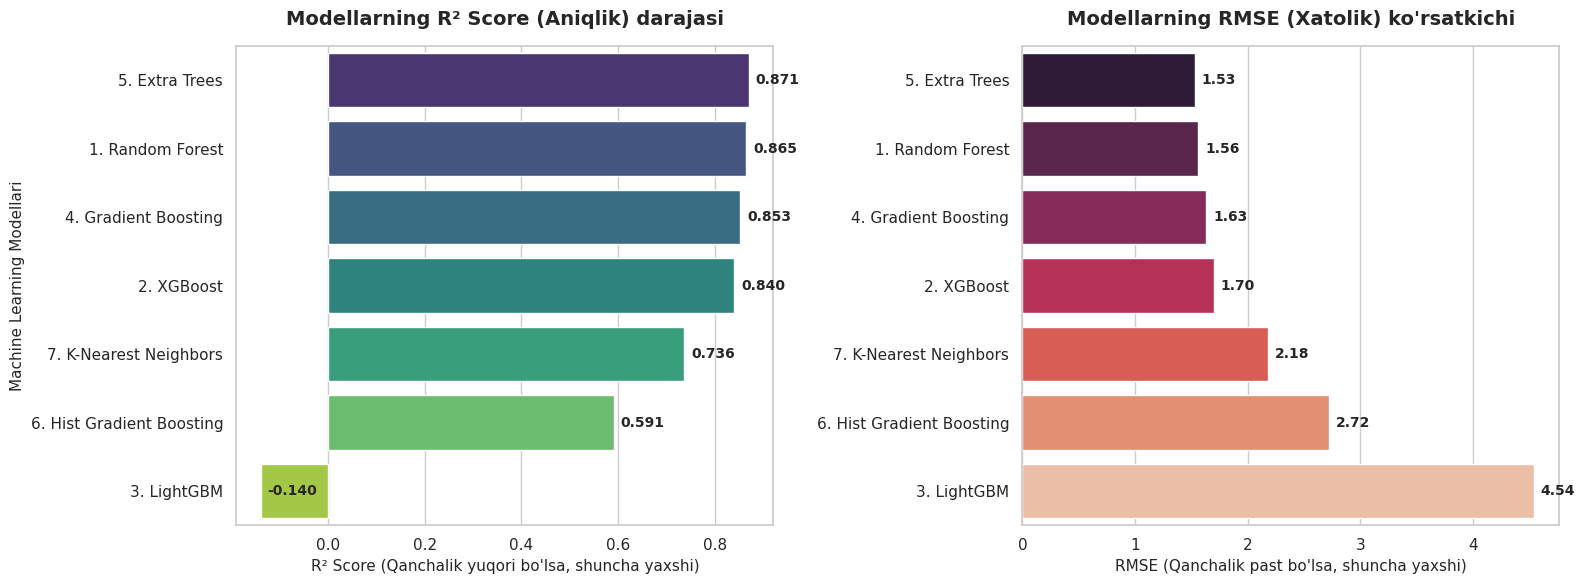

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Seaborn dizaynini sozlash
sns.set_theme(style="whitegrid")

# 1. Natijalar DataFrame'ini tayyorlash (avvalgi koddan chiqqan results_df)
# Agar yuqoridagi kod ishga tushirilgan bo'lsa, results_df ishlatiladi:
results_df = pd.DataFrame(results).sort_values(by="R² Score (Aniqlik)", ascending=False)

# 2. Grafik oynasini yaratish (1 qator, 2 ta ustun)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Birinchi grafik: R² Score (Aniqlik) ---
sns.barplot(
    data=results_df,
    x="R² Score (Aniqlik)",
    y="Model nomi",
    ax=axes[0],
    palette="viridis"
)
axes[0].set_title("Modellarning R² Score (Aniqlik) darajasi", fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel("R² Score (Qanchalik yuqori bo'lsa, shuncha yaxshi)", fontsize=11)
axes[0].set_ylabel("Machine Learning Modellari", fontsize=11)

# Ustunlar ustiga aniq qiymatlarni yozish
for p in axes[0].patches:
    width = p.get_width()
    axes[0].annotate(f'{width:.3f}',
                     (width, p.get_y() + p.get_height() / 2.),
                     ha='left', va='center',
                     xytext=(5, 0), textcoords='offset points', fontsize=10, fontweight='bold')

# --- Ikkinchi grafik: RMSE (Xatolik) ---
sns.barplot(
    data=results_df,
    x="RMSE (Xatolik)",
    y="Model nomi",
    ax=axes[1],
    palette="rocket"
)
axes[1].set_title("Modellarning RMSE (Xatolik) ko'rsatkichi", fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel("RMSE (Qanchalik past bo'lsa, shuncha yaxshi)", fontsize=11)
axes[1].set_ylabel("") # Takrorlanmasligi uchun bo'sh qoldiramiz

# Ustunlar ustiga aniq qiymatlarni yozish
for p in axes[1].patches:
    width = p.get_width()
    axes[1].annotate(f'{width:.2f}',
                     (width, p.get_y() + p.get_height() / 2.),
                     ha='left', va='center',
                     xytext=(5, 0), textcoords='offset points', fontsize=10, fontweight='bold')

# Chizmalarni tekislash va ko'rsatish
plt.tight_layout()
plt.show()